Train accuracy: 0.9938
Validation accuracy: 0.9752


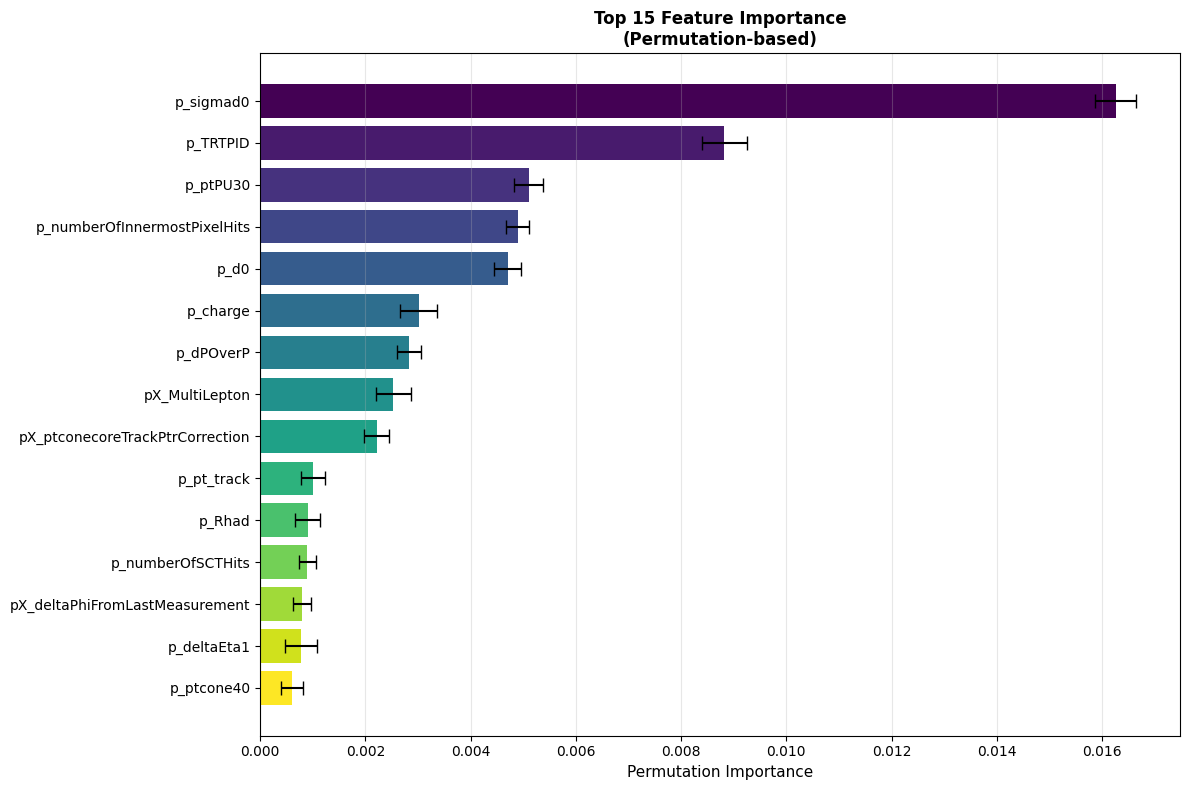

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier


# Load data
class_train_data = pd.read_csv('../Data/AppML_InitialProject_train.csv')
class_test_data = pd.read_csv('../Data/AppML_InitialProject_test_classification.csv')

# Prepare features and target
target = class_train_data['p_Truth_isElectron']
variables = class_train_data.drop(columns=['p_Truth_isElectron', 'p_Truth_Energy'])

# Split into train/validation for calculating importance on unseen data
X_train, X_val, y_train, y_val = train_test_split(
    variables, target, test_size=0.2, random_state=42, stratify=target
)

# Train XGBoost model
model = XGBClassifier(
    n_estimators = 700,
    max_depth = 7,
    learning_rate = 0.04,
    subsample = 0.6,
    colsample_bytree = 0.85,
    gamma = 2.4,
    min_child_weight = 7,
    eval_metric = 'logloss',
    random_state = 42,
    n_jobs = -1
)

model.fit(X_train, y_train)

# Evaluate on validation set
train_score = model.score(X_train, y_train)
val_score = model.score(X_val, y_val)
print(f'Train accuracy: {train_score:.4f}')
print(f'Validation accuracy: {val_score:.4f}')

# Calculate permutation importance on validation set
perm_importance = permutation_importance(
    model, X_val, y_val,
    n_repeats = 10,
    random_state = 42,
    n_jobs = -1
)

# Create results dataframe
importance_df = pd.DataFrame({
    'feature': variables.columns,
    'importance': perm_importance.importances_mean,
    'std': perm_importance.importances_std
}).sort_values('importance', ascending=False)

# Bar plot
top_n = 15
top_features = importance_df.head(top_n)
colors = plt.cm.viridis(np.linspace(0, 1, len(top_features)))
plt.figure(figsize=(12, 8))
plt.barh(top_features['feature'], top_features['importance'], 
         xerr=top_features['std'], color=colors, capsize=5)
plt.xlabel('Permutation Importance', fontsize=11)
plt.title(f'Top {top_n} Feature Importance\n(Permutation-based)', fontsize=12, fontweight='bold')
plt.gca().invert_yaxis()
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()

In [7]:
# Retrain with top features
top_feature_names = top_features['feature'].tolist()
X_train_top = X_train[top_feature_names]
X_val_top = X_val[top_feature_names]

model_top = XGBClassifier(
    n_estimators=500,
    max_depth=6,
    learning_rate=0.05,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

model_top.fit(X_train_top, y_train)
train_score_top = model_top.score(X_train_top, y_train)
val_score_top = model_top.score(X_val_top, y_val)

print(f'Train accuracy with top features: {train_score_top:.4f}')
print(f'Validation accuracy with top features: {val_score_top:.4f}')

Train accuracy with top features: 0.9821
Validation accuracy with top features: 0.9712


In [8]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Hyperparameter tuning for XGBoost on the reduced 15-feature set
# Narrow the search slightly around the current best settings.
param_distributions = {
    'n_estimators': randint(650, 1001),
    'max_depth': randint(5, 10),
    'learning_rate': uniform(0.025, 0.05),
    'subsample': uniform(0.45, 0.18),
    'colsample_bytree': uniform(0.85, 0.15),
    'gamma': uniform(1.5, 2.5),
    'min_child_weight': randint(2, 7)
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=-1),
    param_distributions=param_distributions,
    n_iter=500,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(X_train_top, y_train)

print(f'Best CV score: {random_search.best_score_:.4f}')
print(f'Best parameters: {random_search.best_params_}')

best_model = random_search.best_estimator_
val_score_tuned = best_model.score(X_val_top, y_val)
print(f'Validation accuracy after tuning: {val_score_tuned:.4f}')

Fitting 5 folds for each of 500 candidates, totalling 2500 fits
Best CV score: 0.9724
Best parameters: {'colsample_bytree': np.float64(0.8613407560925126), 'gamma': np.float64(2.4142018706534283), 'learning_rate': np.float64(0.036269063400338294), 'max_depth': 8, 'min_child_weight': 3, 'n_estimators': 675, 'subsample': np.float64(0.6024949990260448)}
Validation accuracy after tuning: 0.9720


In [9]:
from pathlib import Path

# Load test data and extract top features
X_test = class_test_data[top_feature_names]

# Get probability predictions for class 1 (electron)
test_predictions = best_model.predict_proba(X_test)[:, 1]

# Define output paths and filenames
solution_name = "XGBoost"
name = "BenjaminSiddique"
output_dir = Path('../Classification/Output')
output_dir.mkdir(exist_ok=True)

# Export predictions
predictions_filename = f"Classification_{name}_{solution_name}.csv"
predictions_filepath = output_dir / predictions_filename
with open(predictions_filepath, 'w') as f:
    for idx, pred in enumerate(test_predictions):
        f.write(f"{idx},{pred:.6f}\n")

#Export chosen features
varlist_filename = f"Classification_{name}_{solution_name}_VariableList.csv"
varlist_filepath = output_dir / varlist_filename
with open(varlist_filepath, 'w') as f:
    for var in top_feature_names:
        f.write(f"{var}\n")

In [10]:
import sys, subprocess

returncode = subprocess.run([sys.executable, "../SubmissionChecker.py", str(output_dir.resolve())])

if returncode.returncode == 0:
    print("\n✓ Submission files passed validation checks.")
else:
    print("\n✗ Submission files failed validation checks. Please review the output above for details.")


✓ Submission files passed validation checks.
